# Country-level Economic Freedom Index

In this notebook I build a simple country-level Economic Freedom Index from raw World Development Indicators (WDI) data.

## 1. What is being built here?

The final index is based on four sub-indices:
- Rule of Law
- Government Size
- Regulatory Efficiency
- Open Markets

Each sub-index is built from raw indicators rather than from an existing ready-made index.

An **indicator** is just one measurable variable. For example:
- inflation
- trade as a share of GDP
- government expenditure as a share of GDP
- rule of law score

Later in the notebook, these indicators are put on the same 0-100 scale so that they can be combined into sub-indices and then into one final index.

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_colwidth", 120)

## 2. What are WDI and WGI?

Two local data sources are used.

**WDI** means *World Development Indicators*.
- This is a large World Bank dataset.
- It contains many country-level indicators.
- In the raw file, one row is one country + one indicator, and the years are spread across columns.

**WGI** means *Worldwide Governance Indicators*.
- This is also a World Bank dataset.
- It contains governance measures such as rule of law, control of corruption, and regulatory quality.

So the rough plan is:
1. take economic indicators from WDI
2. take governance indicators from WGI
3. convert them into one country-level master table
4. normalise them
5. build sub-indices
6. build the final Economic Freedom Index

In [65]:
source_files = pd.DataFrame(
    [
        ["WDICSV.csv", "WDI values", "Raw country-indicator values by year"],
        ["WDICountry.csv", "WDI country metadata", "Used to keep countries and remove regional aggregates"],
        ["WDISeries.csv", "WDI indicator metadata", "Used to understand indicator names and units"],
        ["wgidataset_with_sourcedata-2025.xlsx", "WGI values", "Governance indicators such as rule of law and regulatory quality"],
    ],
    columns=["file_name", "dataset", "how_it_is_used"],
)

display(source_files)

,file_name,dataset,how_it_is_used
0,WDICSV.csv,WDI values,Raw country-indicator values by year
1,WDICountry.csv,WDI country metadata,Used to keep countries and remove regional aggregates
2,WDISeries.csv,WDI indicator metadata,Used to understand indicator names and units
3,wgidataset_with_sourcedata-2025.xlsx,WGI values,Governance indicators such as rule of law and regulatory quality


## 3. Which indicators will be used?

The index uses a short list of indicators.

For each indicator I need to know:
- which source it comes from
- what it measures
- which sub-index it belongs to
- whether a higher value is good or bad for economic freedom

In [66]:
indicator_plan = pd.DataFrame(
    [
        ["WGI", "rl", "Rule of law", "Rule of Law", "Higher is better", "Captures trust in rules, courts, and property rights"],
        ["WGI", "cc", "Control of corruption", "Rule of Law", "Higher is better", "Captures how strongly corruption is controlled"],
        ["WGI", "rq", "Regulatory quality", "Regulatory Efficiency", "Higher is better", "Captures whether regulation supports private sector activity"],
        ["WDI", "GC.XPN.TOTL.GD.ZS", "Expense (% of GDP)", "Government Size", "Lower is better", "Larger government spending means a larger state footprint"],
        ["WDI", "NE.CON.GOVT.ZS", "General government final consumption expenditure (% of GDP)", "Government Size", "Lower is better", "Measures how much of output is used for government consumption"],
        ["WDI", "NE.TRD.GNFS.ZS", "Trade (% of GDP)", "Open Markets", "Higher is better", "More trade openness usually means fewer barriers to exchange"],
        ["WDI", "TM.TAX.MANF.SM.AR.ZS", "Tariff rate, applied, simple mean, manufactured products (%)", "Open Markets", "Lower is better", "Higher tariffs mean more trade restriction"],
        ["WDI", "BX.KLT.DINV.WD.GD.ZS", "Foreign direct investment, net inflows (% of GDP)", "Open Markets", "Higher is better", "Higher FDI suggests a more open environment for capital"],
        ["WDI", "FP.CPI.TOTL.ZG", "Inflation, consumer prices (annual %)", "Open Markets", "Lower is better", "Very high inflation weakens monetary stability"],
    ],
    columns=["source", "indicator_code", "indicator_name", "dimension", "direction", "meaning"],
)

display(indicator_plan)

,source,indicator_code,indicator_name,dimension,direction,meaning
0,WGI,rl,Rule of law,Rule of Law,Higher is better,"Captures trust in rules, courts, and property rights"
1,WGI,cc,Control of corruption,Rule of Law,Higher is better,Captures how strongly corruption is controlled
2,WGI,rq,Regulatory quality,Regulatory Efficiency,Higher is better,Captures whether regulation supports private sector activity
3,WDI,GC.XPN.TOTL.GD.ZS,Expense (% of GDP),Government Size,Lower is better,Larger government spending means a larger state footprint
4,WDI,NE.CON.GOVT.ZS,General government final consumption expenditure (% of GDP),Government Size,Lower is better,Measures how much of output is used for government consumption
5,WDI,NE.TRD.GNFS.ZS,Trade (% of GDP),Open Markets,Higher is better,More trade openness usually means fewer barriers to exchange
6,WDI,TM.TAX.MANF.SM.AR.ZS,"Tariff rate, applied, simple mean, manufactured products (%)",Open Markets,Lower is better,Higher tariffs mean more trade restriction
7,WDI,BX.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net inflows (% of GDP)",Open Markets,Higher is better,Higher FDI suggests a more open environment for capital
8,WDI,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",Open Markets,Lower is better,Very high inflation weakens monetary stability


In [67]:
dimension_plan = pd.DataFrame(
    [
        ["Rule of Law", "Average of rule of law and control of corruption"],
        ["Government Size", "Average of reversed government expense and reversed government consumption"],
        ["Regulatory Efficiency", "Regulatory quality score"],
        ["Open Markets", "Average of trade openness, reversed tariff, FDI inflows, and reversed inflation"],
    ],
    columns=["sub_index", "how_it_will_be_calculated"],
)

display(dimension_plan)

,sub_index,how_it_will_be_calculated
0,Rule of Law,Average of rule of law and control of corruption
1,Government Size,Average of reversed government expense and reversed government consumption
2,Regulatory Efficiency,Regulatory quality score
3,Open Markets,"Average of trade openness, reversed tariff, FDI inflows, and reversed inflation"


In [68]:
wdi_series = pd.read_csv("WDISeries.csv")
wdi_series_selected = wdi_series[wdi_series["Series Code"].isin(indicator_plan.loc[indicator_plan["source"] == "WDI", "indicator_code"])].copy()
wdi_series_selected = wdi_series_selected[["Series Code", "Indicator Name", "Topic", "Unit of measure"]]
wdi_series_selected = wdi_series_selected.sort_values("Series Code").reset_index(drop=True)

display(wdi_series_selected)

,Series Code,Indicator Name,Topic,Unit of measure
0,BX.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net inflows (% of GDP)",Economic Policy & Debt: Balance of payments: Capital & financial account,NaN
1,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual % growth)",Financial Sector: Exchange rates & prices,%
2,GC.XPN.TOTL.GD.ZS,Expense (% of GDP),Public Sector: Government finance: Expense,%
3,NE.CON.GOVT.ZS,General government final consumption expenditure (% of GDP),Economic Policy & Debt: National accounts: Shares of GDP & other,%
4,NE.TRD.GNFS.ZS,Trade (% of GDP),Economic Policy & Debt: National accounts: Shares of GDP & other,%
5,TM.TAX.MANF.SM.AR.ZS,"Tariff rate, applied, simple mean, manufactured products (%)",Trade,NaN


## 4. Keep countries and remove aggregates

The WDI country file includes both:
- real countries
- grouped areas such as regions or aggregates

This project is a country-level index, so regional aggregates should not be mixed with countries.

In [69]:
countries = pd.read_csv("WDICountry.csv")

print("Rows in WDICountry.csv:", len(countries))
display(countries[["Country Code", "Short Name", "Region", "Income Group"]].head(10))

Rows in WDICountry.csv: 265


,Country Code,Short Name,Region,Income Group
0,ABW,Aruba,Latin America & Caribbean,High income
1,AFE,Africa Eastern and Southern,NaN,NaN
2,AFG,Afghanistan,Middle East & North Africa,Low income
3,AFW,Africa Western and Central,NaN,NaN
4,AGO,Angola,Sub-Saharan Africa,Lower middle income
5,ALB,Albania,Europe & Central Asia,Upper middle income
6,AND,Andorra,Europe & Central Asia,High income
7,ARB,Arab World,NaN,NaN
8,ARE,United Arab Emirates,Middle East & North Africa,High income
9,ARG,Argentina,Latin America & Caribbean,Upper middle income


In [70]:
country_meta = countries[countries["Region"].notna()].copy()
country_meta = country_meta[["Country Code", "Short Name", "Region", "Income Group"]]
country_meta = country_meta.rename(columns={"Short Name": "country_name", "Country Code": "country_code", "Region": "region", "Income Group": "income_group"})

print("Country rows kept:", len(country_meta))
print("Rows dropped as aggregates or special groups:", len(countries) - len(country_meta))
display(country_meta.head(10))

Country rows kept: 217
Rows dropped as aggregates or special groups: 48


,country_code,country_name,region,income_group
0,ABW,Aruba,Latin America & Caribbean,High income
2,AFG,Afghanistan,Middle East & North Africa,Low income
4,AGO,Angola,Sub-Saharan Africa,Lower middle income
5,ALB,Albania,Europe & Central Asia,Upper middle income
6,AND,Andorra,Europe & Central Asia,High income
8,ARE,United Arab Emirates,Middle East & North Africa,High income
9,ARG,Argentina,Latin America & Caribbean,Upper middle income
10,ARM,Armenia,Europe & Central Asia,Upper middle income
11,ASM,American Samoa,East Asia & Pacific,High income
12,ATG,Antigua and Barbuda,Latin America & Caribbean,High income


## 5. Choose the time rule

The data files contain many years, so I need one rule to decide which year enters the final country table.

I will compare these options:
- 2022 only
- 2023 only
- 2024 only
- latest available value up to 2023

In [71]:
compare_cols = ["Country Code", "Indicator Code", "2019", "2020", "2021", "2022", "2023", "2024"]
wdi_compare = pd.read_csv("WDICSV.csv", usecols=compare_cols)
wdi_compare = wdi_compare[wdi_compare["Country Code"].isin(country_meta["country_code"])]
wdi_compare = wdi_compare[wdi_compare["Indicator Code"].isin(indicator_plan.loc[indicator_plan["source"] == "WDI", "indicator_code"])]

coverage_rows = []
for code_value in indicator_plan.loc[indicator_plan["source"] == "WDI", "indicator_code"]:
    part = wdi_compare[wdi_compare["Indicator Code"] == code_value]
    coverage_rows.append(
        {
            "indicator_code": code_value,
            "2022 only": int(part["2022"].notna().sum()),
            "2023 only": int(part["2023"].notna().sum()),
            "2024 only": int(part["2024"].notna().sum()),
            "latest up to 2023": int(part[["2019", "2020", "2021", "2022", "2023"]].notna().any(axis=1).sum()),
        }
    )

coverage_table = pd.DataFrame(coverage_rows).merge(
    indicator_plan[["indicator_code", "indicator_name", "dimension"]],
    on="indicator_code",
    how="left",
)

display(coverage_table)

,indicator_code,2022 only,2023 only,2024 only,latest up to 2023,indicator_name,dimension
0,GC.XPN.TOTL.GD.ZS,111,87,2,142,Expense (% of GDP),Government Size
1,NE.CON.GOVT.ZS,173,166,125,176,General government final consumption expenditure (% of GDP),Government Size
2,NE.TRD.GNFS.ZS,182,173,160,183,Trade (% of GDP),Open Markets
3,TM.TAX.MANF.SM.AR.ZS,143,0,0,180,"Tariff rate, applied, simple mean, manufactured products (%)",Open Markets
4,BX.KLT.DINV.WD.GD.ZS,195,195,186,196,"Foreign direct investment, net inflows (% of GDP)",Open Markets
5,FP.CPI.TOTL.ZG,178,176,171,184,"Inflation, consumer prices (annual %)",Open Markets


In [72]:
rule_summary = []
rule_map = {
    "2022 only": ["2022"],
    "2023 only": ["2023"],
    "2024 only": ["2024"],
    "latest up to 2023": ["2019", "2020", "2021", "2022", "2023"],
}

for rule_name, years in rule_map.items():
    temp = wdi_compare[["Country Code", "Indicator Code"] + years].copy()
    temp["has_value"] = temp[years].notna().any(axis=1)
    temp = temp.pivot_table(index="Country Code", columns="Indicator Code", values="has_value", aggfunc="first")
    temp = temp.fillna(False)
    rule_summary.append(
        {
            "rule": rule_name,
            "countries_with_all_selected_WDI_indicators": int(temp.all(axis=1).sum()),
        }
    )

rule_summary = pd.DataFrame(rule_summary)
display(rule_summary)

,rule,countries_with_all_selected_WDI_indicators
0,2022 only,88
1,2023 only,0
2,2024 only,0
3,latest up to 2023,123


In [73]:
TARGET_YEAR = 2023
LOOKBACK_YEARS = ["2019", "2020", "2021", "2022", "2023"]

print("Chosen rule: latest available value up to", TARGET_YEAR)
print("Lookback years used for WDI:", LOOKBACK_YEARS)

Chosen rule: latest available value up to 2023
Lookback years used for WDI: ['2019', '2020', '2021', '2022', '2023']


## 6. Load WDI data and convert it into long format

The raw WDI file is in a wide format:
- one row = one country + one indicator
- each year is a separate column

For analysis it is easier to work in a long format:
- one row = one country + one indicator + one year + one value

In [74]:
wdi_cols = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"] + LOOKBACK_YEARS
wdi_raw = pd.read_csv("WDICSV.csv", usecols=wdi_cols)
wdi_raw = wdi_raw[wdi_raw["Country Code"].isin(country_meta["country_code"])]
wdi_raw = wdi_raw[wdi_raw["Indicator Code"].isin(indicator_plan.loc[indicator_plan["source"] == "WDI", "indicator_code"])]
wdi_raw = wdi_raw.sort_values(["Indicator Code", "Country Code"]).reset_index(drop=True)

print("Selected WDI rows:", len(wdi_raw))
display(wdi_raw.head(10))

Selected WDI rows: 1302


,Country Name,Country Code,Indicator Name,Indicator Code,2019,2020,2021,2022,2023
0,Aruba,ABW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,-2.25,6.52,4.64,7.47,-3.58
1,Afghanistan,AFG,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,0.12,0.06,0.14,NaN,NaN
2,Angola,AGO,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,-5.08,-3.17,-5.47,-5.03,-1.98
3,Albania,ALB,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,7.71,7.02,6.76,7.58,6.90
4,Andorra,AND,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,13.38,9.43,14.58,17.57,7.29
5,United Arab Emirates,ARE,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,4.12,5.57,4.89,4.45,5.87
6,Argentina,ARG,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,1.49,1.27,1.37,2.40,3.81
7,Armenia,ARM,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,0.74,0.46,2.64,5.00,2.40
8,American Samoa,ASM,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN
9,Antigua and Barbuda,ATG,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,7.76,6.83,17.89,16.38,14.61


In [75]:
wdi_long = wdi_raw.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=LOOKBACK_YEARS,
    var_name="year",
    value_name="value_raw",
)

wdi_long = wdi_long.dropna(subset=["value_raw"]).copy()
wdi_long["year"] = wdi_long["year"].astype(int)
wdi_long = wdi_long.sort_values(["Country Code", "Indicator Code", "year"]).reset_index(drop=True)

print("Non-missing WDI observations in long format:", len(wdi_long))
display(wdi_long.head(10))

Non-missing WDI observations in long format: 4826


,Country Name,Country Code,Indicator Name,Indicator Code,year,value_raw
0,Aruba,ABW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,2019,-2.25
1,Aruba,ABW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,2020,6.52
2,Aruba,ABW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,2021,4.64
3,Aruba,ABW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,2022,7.47
4,Aruba,ABW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,2023,-3.58
5,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2019,4.26
6,Aruba,ABW,General government final consumption expenditure (% of GDP),NE.CON.GOVT.ZS,2019,22.91
7,Aruba,ABW,General government final consumption expenditure (% of GDP),NE.CON.GOVT.ZS,2020,29.16
8,Aruba,ABW,General government final consumption expenditure (% of GDP),NE.CON.GOVT.ZS,2021,22.85
9,Aruba,ABW,General government final consumption expenditure (% of GDP),NE.CON.GOVT.ZS,2022,20.36


In [76]:
wdi_latest = wdi_long.sort_values(["Country Code", "Indicator Code", "year"], ascending=[True, True, False]).drop_duplicates(["Country Code", "Indicator Code"])
wdi_latest = wdi_latest.merge(
    indicator_plan[["indicator_code", "dimension", "direction", "meaning"]].rename(columns={"indicator_code": "Indicator Code"}),
    on="Indicator Code",
    how="left",
)
wdi_latest["source"] = "WDI"
wdi_latest["year_used"] = wdi_latest["year"]
wdi_latest = wdi_latest.rename(columns={"Country Name": "country_name", "Country Code": "country_code", "Indicator Name": "indicator_name", "Indicator Code": "indicator_code"})

print("Latest selected WDI rows:", len(wdi_latest))
display(wdi_latest[["country_name", "country_code", "indicator_code", "indicator_name", "year_used", "value_raw", "dimension", "direction"]].head(10))

year_used_table = wdi_latest.groupby(["indicator_code", "year_used"]).size().reset_index(name="countries")
display(year_used_table.head(20))


Latest selected WDI rows: 1061


,country_name,country_code,indicator_code,indicator_name,year_used,value_raw,dimension,direction
0,Aruba,ABW,BX.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net inflows (% of GDP)",2023,-3.58,Open Markets,Higher is better
1,Aruba,ABW,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",2019,4.26,Open Markets,Lower is better
2,Aruba,ABW,NE.CON.GOVT.ZS,General government final consumption expenditure (% of GDP),2023,18.90,Government Size,Lower is better
3,Aruba,ABW,NE.TRD.GNFS.ZS,Trade (% of GDP),2023,159.02,Open Markets,Higher is better
4,Aruba,ABW,TM.TAX.MANF.SM.AR.ZS,"Tariff rate, applied, simple mean, manufactured products (%)",2021,10.87,Open Markets,Lower is better
5,Afghanistan,AFG,BX.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net inflows (% of GDP)",2021,0.14,Open Markets,Higher is better
6,Afghanistan,AFG,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",2023,-4.64,Open Markets,Lower is better
7,Afghanistan,AFG,NE.CON.GOVT.ZS,General government final consumption expenditure (% of GDP),2023,21.21,Government Size,Lower is better
8,Afghanistan,AFG,NE.TRD.GNFS.ZS,Trade (% of GDP),2023,67.58,Open Markets,Higher is better
9,Angola,AGO,BX.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net inflows (% of GDP)",2023,-1.98,Open Markets,Higher is better


,indicator_code,year_used,countries
0,BX.KLT.DINV.WD.GD.ZS,2021,1
1,BX.KLT.DINV.WD.GD.ZS,2023,195
2,FP.CPI.TOTL.ZG,2019,5
3,FP.CPI.TOTL.ZG,2022,3
4,FP.CPI.TOTL.ZG,2023,176
5,GC.XPN.TOTL.GD.ZS,2019,4
6,GC.XPN.TOTL.GD.ZS,2020,11
7,GC.XPN.TOTL.GD.ZS,2021,15
8,GC.XPN.TOTL.GD.ZS,2022,25
9,GC.XPN.TOTL.GD.ZS,2023,87


## 7. Load WGI data

For this project I will use only three WGI indicators:
- `rl` = rule of law
- `cc` = control of corruption
- `rq` = regulatory quality

In [77]:
wgi_sample = pd.read_excel("wgidataset_with_sourcedata-2025.xlsx", sheet_name="rl")
display(wgi_sample.head(10))

,ID variable (economy code/ gov. dimension/ year),Economy (name),Economy (code),Region,Income classification,Year,Governance dimension,Number of sources,Governance estimate (approx. -2.5 to +2.5),Standard error (estimate),Lower threshold (90% conf. int. estimate),Upper threshold (90% conf. int. estimate),Governance score (0-100),Standard error (gov. score),Lower threshold (90% conf. int. score),Upper threshold (90% conf. int. score),ADB mean,AFR mean,ARB mean,ASB mean,ASD mean,BPS mean,BTI mean,CCR mean,EBR mean,EIU mean,EQI mean,EUB mean,FRH mean,GCB mean,GCS mean,GII mean,GWP mean,HER mean,HRM mean,HUM mean,IFD mean,IJT mean,IRP mean,LBO mean,MSI mean,OBI mean,PIA mean,PRS mean,RSF mean,VAB mean,VDM mean,WBS mean,WCY mean,WJP mean,WMO mean
0,ADOrl1996,Andorra,ADO,NaN,NaN,1996,rl,2,0.99,0.42,0.30,1.69,74.03,7.30,62.05,86.01,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,0.50,..,..,..,..,..,..,..,..,..,..,..,..,..,..,0.94
1,AFGrl1996,Afghanistan,AFG,South Asia,Low income,1996,rl,3,-1.92,0.38,-2.55,-1.29,23.97,6.61,13.12,34.82,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,0,..,..,..,..,..,..,..,..,..,..,0.06,..,..,..,0.19
2,AGOrl1996,Angola,AGO,Sub-Saharan Africa,Lower middle income,1996,rl,6,-1.57,0.21,-1.91,-1.23,29.94,3.59,24.06,35.82,..,..,..,..,..,..,..,..,..,0.07,..,..,..,..,..,..,..,0.30,..,0,..,..,..,..,..,..,..,0.33,..,..,0.22,..,..,..,0.25
3,ALBrl1996,Albania,ALB,Europe & Central Asia,Upper middle income,1996,rl,6,-0.39,0.25,-0.81,0.02,50.17,4.38,42.99,57.36,..,..,..,..,..,..,..,..,..,..,..,..,0.38,..,..,..,..,0.50,..,0.50,..,..,..,..,..,..,..,0.67,..,..,0.74,..,..,..,0.25
4,ARErl1996,United Arab Emirates,ARE,Middle East & North Africa,High income,1996,rl,6,0.63,0.21,0.29,0.97,67.75,3.59,61.87,73.63,..,..,..,..,..,..,..,..,..,0.53,..,..,..,..,..,..,..,0.90,..,1,..,..,..,..,..,..,..,0.67,..,..,0.28,..,..,..,0.88
5,ARGrl1996,Argentina,ARG,Latin America & Caribbean,Upper middle income,1996,rl,9,0.13,0.19,-0.17,0.43,59.19,3.19,53.96,64.42,..,..,..,..,..,..,..,..,..,0.50,..,..,..,..,0.46,..,..,0.70,..,0.50,..,..,..,0.40,..,..,..,0.83,..,..,0.74,..,0.33,..,0.62
6,ARMrl1996,Armenia,ARM,Europe & Central Asia,Upper middle income,1996,rl,5,-0.26,0.28,-0.72,0.19,52.43,4.76,44.63,60.24,..,..,..,..,..,..,..,..,..,..,..,..,0.38,..,..,..,..,0.50,..,0.50,..,..,..,..,..,..,..,..,..,..,0.46,..,..,..,0.50
7,ATGrl1996,Antigua and Barbuda,ATG,Latin America & Caribbean,High income,1996,rl,2,0.98,0.42,0.28,1.68,73.82,7.30,61.84,85.80,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,1,..,..,..,..,..,..,..,..,..,..,..,..,..,..,0.81
8,AUSrl1996,Australia,AUS,East Asia & Pacific,High income,1996,rl,8,1.69,0.19,1.38,2.00,86.05,3.22,80.78,91.33,..,..,..,..,..,..,..,..,..,0.90,..,..,..,..,0.75,..,..,0.90,..,1,..,..,..,..,..,..,..,1,..,..,0.97,..,0.77,..,0.94
9,AUTrl1996,Austria,AUT,Europe & Central Asia,High income,1996,rl,8,1.84,0.19,1.53,2.15,88.65,3.22,83.38,93.92,..,..,..,..,..,..,..,..,..,0.92,..,..,..,..,0.82,..,..,0.90,..,1,..,..,..,..,..,..,..,1,..,..,0.92,..,0.85,..,1


In [78]:
wgi_frames = []
for indicator_code in ["rl", "cc", "rq"]:
    temp = pd.read_excel("wgidataset_with_sourcedata-2025.xlsx", sheet_name=indicator_code)
    temp = temp[temp["Year"] == TARGET_YEAR].copy()
    temp = temp[temp["Economy (code)"].isin(country_meta["country_code"])]
    temp["indicator_code"] = indicator_code
    temp["indicator_name"] = indicator_plan.loc[indicator_plan["indicator_code"] == indicator_code, "indicator_name"].iloc[0]
    temp["country_name"] = temp["Economy (name)"]
    temp["country_code"] = temp["Economy (code)"]
    temp["value_raw"] = temp["Governance estimate (approx. -2.5 to +2.5)"]
    temp["year_used"] = temp["Year"]
    temp["dimension"] = indicator_plan.loc[indicator_plan["indicator_code"] == indicator_code, "dimension"].iloc[0]
    temp["direction"] = indicator_plan.loc[indicator_plan["indicator_code"] == indicator_code, "direction"].iloc[0]
    temp["meaning"] = indicator_plan.loc[indicator_plan["indicator_code"] == indicator_code, "meaning"].iloc[0]
    temp["source"] = "WGI"
    wgi_frames.append(temp[["country_name", "country_code", "indicator_code", "indicator_name", "value_raw", "year_used", "dimension", "direction", "meaning", "source"]])

wgi_latest = pd.concat(wgi_frames, ignore_index=True)
wgi_latest = wgi_latest.sort_values(["indicator_code", "country_code"]).reset_index(drop=True)

print("Selected WGI rows:", len(wgi_latest))
display(wgi_latest.head(10))

Selected WGI rows: 616


,country_name,country_code,indicator_code,indicator_name,value_raw,year_used,dimension,direction,meaning,source
0,Aruba,ABW,cc,Control of corruption,0.87,2023,Rule of Law,Higher is better,Captures how strongly corruption is controlled,WGI
1,Afghanistan,AFG,cc,Control of corruption,-1.20,2023,Rule of Law,Higher is better,Captures how strongly corruption is controlled,WGI
2,Angola,AGO,cc,Control of corruption,-0.62,2023,Rule of Law,Higher is better,Captures how strongly corruption is controlled,WGI
3,Albania,ALB,cc,Control of corruption,-0.46,2023,Rule of Law,Higher is better,Captures how strongly corruption is controlled,WGI
4,United Arab Emirates,ARE,cc,Control of corruption,0.99,2023,Rule of Law,Higher is better,Captures how strongly corruption is controlled,WGI
5,Argentina,ARG,cc,Control of corruption,-0.35,2023,Rule of Law,Higher is better,Captures how strongly corruption is controlled,WGI
6,Armenia,ARM,cc,Control of corruption,0.10,2023,Rule of Law,Higher is better,Captures how strongly corruption is controlled,WGI
7,American Samoa,ASM,cc,Control of corruption,1.17,2023,Rule of Law,Higher is better,Captures how strongly corruption is controlled,WGI
8,Antigua and Barbuda,ATG,cc,Control of corruption,0.27,2023,Rule of Law,Higher is better,Captures how strongly corruption is controlled,WGI
9,Australia,AUS,cc,Control of corruption,1.81,2023,Rule of Law,Higher is better,Captures how strongly corruption is controlled,WGI


## 8. Build one master table

Now both sources can be stacked into one master table.

This is an important step because from this point on I can track:
- country
- indicator
- source
- year used
- raw value
- direction
- sub-index membership

In [79]:
wdi_master = wdi_latest[["country_name", "country_code", "indicator_code", "indicator_name", "value_raw", "year_used", "dimension", "direction", "meaning", "source"]].copy()
wgi_master = wgi_latest.copy()

master_long = pd.concat([wdi_master, wgi_master], ignore_index=True)
master_long = master_long.merge(country_meta, on=["country_code", "country_name"], how="left")
master_long = master_long[["country_name", "country_code", "region", "income_group", "source", "dimension", "indicator_code", "indicator_name", "meaning", "direction", "year_used", "value_raw"]]
master_long = master_long.sort_values(["country_code", "indicator_code"]).reset_index(drop=True)

print("Rows in master long table:", len(master_long))
print("Countries with at least one selected indicator:", master_long["country_code"].nunique())
display(master_long.head(10))

Rows in master long table: 1677
Countries with at least one selected indicator: 212


,country_name,country_code,region,income_group,source,dimension,indicator_code,indicator_name,meaning,direction,year_used,value_raw
0,Aruba,ABW,Latin America & Caribbean,High income,WDI,Open Markets,BX.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net inflows (% of GDP)",Higher FDI suggests a more open environment for capital,Higher is better,2023,-3.58
1,Aruba,ABW,Latin America & Caribbean,High income,WDI,Open Markets,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",Very high inflation weakens monetary stability,Lower is better,2019,4.26
2,Aruba,ABW,Latin America & Caribbean,High income,WDI,Government Size,NE.CON.GOVT.ZS,General government final consumption expenditure (% of GDP),Measures how much of output is used for government consumption,Lower is better,2023,18.90
3,Aruba,ABW,Latin America & Caribbean,High income,WDI,Open Markets,NE.TRD.GNFS.ZS,Trade (% of GDP),More trade openness usually means fewer barriers to exchange,Higher is better,2023,159.02
4,Aruba,ABW,Latin America & Caribbean,High income,WDI,Open Markets,TM.TAX.MANF.SM.AR.ZS,"Tariff rate, applied, simple mean, manufactured products (%)",Higher tariffs mean more trade restriction,Lower is better,2021,10.87
5,Aruba,ABW,Latin America & Caribbean,High income,WGI,Rule of Law,cc,Control of corruption,Captures how strongly corruption is controlled,Higher is better,2023,0.87
6,Aruba,ABW,Latin America & Caribbean,High income,WGI,Rule of Law,rl,Rule of law,"Captures trust in rules, courts, and property rights",Higher is better,2023,1.22
7,Aruba,ABW,Latin America & Caribbean,High income,WGI,Regulatory Efficiency,rq,Regulatory quality,Captures whether regulation supports private sector activity,Higher is better,2023,0.98
8,Afghanistan,AFG,Middle East & North Africa,Low income,WDI,Open Markets,BX.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net inflows (% of GDP)",Higher FDI suggests a more open environment for capital,Higher is better,2021,0.14
9,Afghanistan,AFG,Middle East & North Africa,Low income,WDI,Open Markets,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",Very high inflation weakens monetary stability,Lower is better,2023,-4.64


In [80]:
master_counts = master_long.groupby(["source", "dimension", "indicator_code"]).agg(
    countries_with_value=("country_code", "nunique"),
    mean_value=("value_raw", "mean"),
).reset_index()

display(master_counts)

,source,dimension,indicator_code,countries_with_value,mean_value
0,WDI,Government Size,GC.XPN.TOTL.GD.ZS,142,27.91
1,WDI,Government Size,NE.CON.GOVT.ZS,176,17.29
2,WDI,Open Markets,BX.KLT.DINV.WD.GD.ZS,196,3.50
3,WDI,Open Markets,FP.CPI.TOTL.ZG,184,11.36
4,WDI,Open Markets,NE.TRD.GNFS.ZS,183,95.66
5,WDI,Open Markets,TM.TAX.MANF.SM.AR.ZS,180,6.89
6,WGI,Regulatory Efficiency,rq,204,-0.04
7,WGI,Rule of Law,cc,206,-0.03
8,WGI,Rule of Law,rl,206,-0.05


## 9. Check missing data

Before building the index we need to see which indicators have missing values.

In [81]:
coverage_summary = master_long.groupby(["indicator_code", "indicator_name", "dimension", "direction"]).agg(
    countries_with_value=("country_code", "nunique"),
    min_year_used=("year_used", "min"),
    max_year_used=("year_used", "max"),
).reset_index()

coverage_summary["missing_countries"] = master_long["country_code"].nunique() - coverage_summary["countries_with_value"]
coverage_summary["coverage_percent"] = 100 * coverage_summary["countries_with_value"] / master_long["country_code"].nunique()

display(coverage_summary.sort_values(["dimension", "indicator_code"]))

,indicator_code,indicator_name,dimension,direction,countries_with_value,min_year_used,max_year_used,missing_countries,coverage_percent
2,GC.XPN.TOTL.GD.ZS,Expense (% of GDP),Government Size,Lower is better,142,2019,2023,70,66.98
3,NE.CON.GOVT.ZS,General government final consumption expenditure (% of GDP),Government Size,Lower is better,176,2020,2023,36,83.02
0,BX.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net inflows (% of GDP)",Open Markets,Higher is better,196,2021,2023,16,92.45
1,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",Open Markets,Lower is better,184,2019,2023,28,86.79
4,NE.TRD.GNFS.ZS,Trade (% of GDP),Open Markets,Higher is better,183,2020,2023,29,86.32
5,TM.TAX.MANF.SM.AR.ZS,"Tariff rate, applied, simple mean, manufactured products (%)",Open Markets,Lower is better,180,2019,2022,32,84.91
8,rq,Regulatory quality,Regulatory Efficiency,Higher is better,204,2023,2023,8,96.23
6,cc,Control of corruption,Rule of Law,Higher is better,206,2023,2023,6,97.17
7,rl,Rule of law,Rule of Law,Higher is better,206,2023,2023,6,97.17


In [82]:
analysis_wide = master_long.pivot_table(index=["country_code", "country_name"], columns="indicator_code", values="value_raw", aggfunc="first").reset_index()

print("Wide analysis table shape:", analysis_wide.shape)
display(analysis_wide.head(10))

missing_before = analysis_wide.isna().sum().reset_index()
missing_before.columns = ["column_name", "missing_values"]
display(missing_before[missing_before["missing_values"] > 0])

Wide analysis table shape: (217, 11)


indicator_code,country_code,country_name,BX.KLT.DINV.WD.GD.ZS,FP.CPI.TOTL.ZG,GC.XPN.TOTL.GD.ZS,NE.CON.GOVT.ZS,NE.TRD.GNFS.ZS,TM.TAX.MANF.SM.AR.ZS,cc,rl,rq
0,ABW,Aruba,-3.58,4.26,NaN,18.90,159.02,10.87,0.87,1.22,0.98
1,AFG,Afghanistan,0.14,-4.64,NaN,21.21,67.58,NaN,-1.20,-1.90,-1.43
2,AGO,Angola,-1.98,13.64,14.65,11.41,53.03,10.19,-0.62,-1.19,-0.90
3,ALB,Albania,6.90,4.76,25.44,12.12,82.35,0.40,-0.46,-0.15,0.06
4,AND,Andorra,7.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ARE,United Arab Emirates,5.87,1.63,3.77,12.22,199.04,4.00,0.99,0.45,1.11
6,ARG,Argentina,3.81,133.49,21.01,16.30,26.68,12.35,-0.35,-0.24,-0.51
7,ARM,Armenia,2.40,1.98,20.95,12.10,123.42,5.57,0.10,-0.21,0.10
8,ASM,American Samoa,NaN,NaN,NaN,NaN,124.68,NaN,1.17,1.19,0.39
9,ATG,Antigua and Barbuda,14.61,5.07,NaN,NaN,117.70,11.51,0.27,0.62,0.62


,column_name,missing_values
2,BX.KLT.DINV.WD.GD.ZS,21
3,FP.CPI.TOTL.ZG,33
4,GC.XPN.TOTL.GD.ZS,75
5,NE.CON.GOVT.ZS,41
6,NE.TRD.GNFS.ZS,34
7,TM.TAX.MANF.SM.AR.ZS,37
8,cc,11
9,rl,11
10,rq,13


## 10. Fill the remaining gaps in a simple way

I want a complete country table before scaling and aggregation.

Here I use a simple rule:
- if a value is missing, replace it with the median for that indicator

This is not the only possible choice, but it is easy to see and easy to reproduce.

In [83]:
analysis_imputed = analysis_wide.copy()
imputation_rows = []

for indicator_code in indicator_plan["indicator_code"]:
    indicator_median = analysis_imputed[indicator_code].median()
    missing_values = int(analysis_imputed[indicator_code].isna().sum())
    analysis_imputed[indicator_code] = analysis_imputed[indicator_code].fillna(indicator_median)
    imputation_rows.append(
        {
            "indicator_code": indicator_code,
            "median_used": indicator_median,
            "missing_values_filled": missing_values,
        }
    )

imputation_table = pd.DataFrame(imputation_rows).merge(
    indicator_plan[["indicator_code", "indicator_name", "dimension"]],
    on="indicator_code",
    how="left",
)

display(imputation_table)
display(analysis_imputed.head(10))

,indicator_code,median_used,missing_values_filled,indicator_name,dimension
0,rl,-0.16,11,Rule of law,Rule of Law
1,cc,-0.20,11,Control of corruption,Rule of Law
2,rq,-0.12,13,Regulatory quality,Regulatory Efficiency
3,GC.XPN.TOTL.GD.ZS,26.65,75,Expense (% of GDP),Government Size
4,NE.CON.GOVT.ZS,16.62,41,General government final consumption expenditure (% of GDP),Government Size
5,NE.TRD.GNFS.ZS,83.38,34,Trade (% of GDP),Open Markets
6,TM.TAX.MANF.SM.AR.ZS,5.55,37,"Tariff rate, applied, simple mean, manufactured products (%)",Open Markets
7,BX.KLT.DINV.WD.GD.ZS,2.14,21,"Foreign direct investment, net inflows (% of GDP)",Open Markets
8,FP.CPI.TOTL.ZG,5.87,33,"Inflation, consumer prices (annual %)",Open Markets


indicator_code,country_code,country_name,BX.KLT.DINV.WD.GD.ZS,FP.CPI.TOTL.ZG,GC.XPN.TOTL.GD.ZS,NE.CON.GOVT.ZS,NE.TRD.GNFS.ZS,TM.TAX.MANF.SM.AR.ZS,cc,rl,rq
0,ABW,Aruba,-3.58,4.26,26.65,18.90,159.02,10.87,0.87,1.22,0.98
1,AFG,Afghanistan,0.14,-4.64,26.65,21.21,67.58,5.55,-1.20,-1.90,-1.43
2,AGO,Angola,-1.98,13.64,14.65,11.41,53.03,10.19,-0.62,-1.19,-0.90
3,ALB,Albania,6.90,4.76,25.44,12.12,82.35,0.40,-0.46,-0.15,0.06
4,AND,Andorra,7.29,5.87,26.65,16.62,83.38,5.55,-0.20,-0.16,-0.12
5,ARE,United Arab Emirates,5.87,1.63,3.77,12.22,199.04,4.00,0.99,0.45,1.11
6,ARG,Argentina,3.81,133.49,21.01,16.30,26.68,12.35,-0.35,-0.24,-0.51
7,ARM,Armenia,2.40,1.98,20.95,12.10,123.42,5.57,0.10,-0.21,0.10
8,ASM,American Samoa,2.14,5.87,26.65,16.62,124.68,5.55,1.17,1.19,0.39
9,ATG,Antigua and Barbuda,14.61,5.07,26.65,16.62,117.70,11.51,0.27,0.62,0.62


## 11. Put all indicators onto the same 0-100 scale

At the moment the indicators are in different units:
- percentages of GDP
- inflation rates
- governance scores

So I do two things:
1. reverse the indicators where lower is better
2. apply min-max scaling to convert everything to a 0-100 scale

After that:
- 0 means the weakest observed position in the sample
- 100 means the strongest observed position in the sample

In [84]:
negative_indicators = indicator_plan.loc[indicator_plan["direction"] == "Lower is better", "indicator_code"].tolist()

adjusted_data = analysis_imputed.copy()
for indicator_code in negative_indicators:
    adjusted_data[indicator_code] = -adjusted_data[indicator_code]

scaled_data = adjusted_data[["country_code", "country_name"]].copy()
scaling_rows = []

for indicator_code in indicator_plan["indicator_code"]:
    min_value = adjusted_data[indicator_code].min()
    max_value = adjusted_data[indicator_code].max()
    scaled_data[indicator_code] = 100 * (adjusted_data[indicator_code] - min_value) / (max_value - min_value)
    scaling_rows.append(
        {
            "indicator_code": indicator_code,
            "adjusted_min": min_value,
            "adjusted_max": max_value,
        }
    )

scaling_table = pd.DataFrame(scaling_rows).merge(
    indicator_plan[["indicator_code", "indicator_name", "direction"]],
    on="indicator_code",
    how="left",
)

display(scaling_table)
display(scaled_data.head(10))

,indicator_code,adjusted_min,adjusted_max,indicator_name,direction
0,rl,-2.20,2.02,Rule of law,Higher is better
1,cc,-1.88,2.32,Control of corruption,Higher is better
2,rq,-2.03,2.13,Regulatory quality,Higher is better
3,GC.XPN.TOTL.GD.ZS,-103.60,-0.00,Expense (% of GDP),Lower is better
4,NE.CON.GOVT.ZS,-57.21,-2.56,General government final consumption expenditure (% of GDP),Lower is better
5,NE.TRD.GNFS.ZS,2.47,402.57,Trade (% of GDP),Higher is better
6,TM.TAX.MANF.SM.AR.ZS,-27.85,-0.00,"Tariff rate, applied, simple mean, manufactured products (%)",Lower is better
7,BX.KLT.DINV.WD.GD.ZS,-63.15,108.81,"Foreign direct investment, net inflows (% of GDP)",Higher is better
8,FP.CPI.TOTL.ZG,-221.34,4.64,"Inflation, consumer prices (annual %)",Lower is better


indicator_code,country_code,country_name,rl,cc,rq,GC.XPN.TOTL.GD.ZS,NE.CON.GOVT.ZS,NE.TRD.GNFS.ZS,TM.TAX.MANF.SM.AR.ZS,BX.KLT.DINV.WD.GD.ZS,FP.CPI.TOTL.ZG
0,ABW,Aruba,81.05,65.44,72.36,74.28,70.10,39.13,60.97,34.64,96.06
1,AFG,Afghanistan,7.20,16.18,14.38,74.28,65.87,16.27,80.05,36.81,100.00
2,AGO,Angola,23.84,29.88,27.03,85.86,83.80,12.64,63.41,35.58,91.91
3,ALB,Albania,48.52,33.70,50.30,75.45,82.50,19.97,98.56,40.74,95.84
4,AND,Andorra,48.46,39.97,45.94,74.28,74.27,20.22,80.05,40.96,95.35
5,ARE,United Arab Emirates,62.79,68.40,75.37,96.36,82.33,49.13,85.64,40.14,97.22
6,ARG,Argentina,46.51,36.32,36.60,79.72,74.85,6.05,55.66,38.94,38.88
7,ARM,Armenia,47.15,47.25,51.10,79.78,82.54,30.23,80.00,38.12,97.07
8,ASM,American Samoa,80.34,72.73,58.17,74.28,74.27,30.55,80.05,37.97,95.35
9,ATG,Antigua and Barbuda,66.79,51.16,63.74,74.28,74.27,28.80,58.67,45.22,95.70


## 12. Build the sub-indices and the final index

Now each country has one comparable 0-100 value for each raw indicator.

The next step is:
1. average the indicators inside each sub-index
2. average the four sub-indices to get the final Economic Freedom Index

In [85]:
sub_index_data = scaled_data[["country_code", "country_name"]].copy()
sub_index_data["Rule of Law"] = scaled_data[["rl", "cc"]].mean(axis=1)
sub_index_data["Government Size"] = scaled_data[["GC.XPN.TOTL.GD.ZS", "NE.CON.GOVT.ZS"]].mean(axis=1)
sub_index_data["Regulatory Efficiency"] = scaled_data["rq"]
sub_index_data["Open Markets"] = scaled_data[["NE.TRD.GNFS.ZS", "TM.TAX.MANF.SM.AR.ZS", "BX.KLT.DINV.WD.GD.ZS", "FP.CPI.TOTL.ZG"]].mean(axis=1)
sub_index_data["Economic Freedom Index"] = sub_index_data[["Rule of Law", "Government Size", "Regulatory Efficiency", "Open Markets"]].mean(axis=1)

sub_index_data = sub_index_data.merge(country_meta, on=["country_code", "country_name"], how="left")
sub_index_data = sub_index_data.sort_values("Economic Freedom Index", ascending=False).reset_index(drop=True)
sub_index_data["Rank"] = np.arange(1, len(sub_index_data) + 1)

display(sub_index_data.head(10))

,country_code,country_name,Rule of Law,Government Size,Regulatory Efficiency,Open Markets,Economic Freedom Index,region,income_group,Rank
0,SGP,Singapore,88.26,84.84,100.00,82.14,88.81,East Asia & Pacific,High income,1
1,CHE,Switzerland,94.68,83.97,92.21,64.23,83.77,Europe & Central Asia,High income,2
2,HKG,"Hong Kong SAR, China",77.34,77.31,90.41,84.99,82.51,East Asia & Pacific,High income,3
3,IRL,Ireland,86.28,82.23,92.01,67.91,82.11,Europe & Central Asia,High income,4
4,LUX,Luxembourg,92.92,65.18,92.97,76.75,81.95,Europe & Central Asia,High income,5
5,DNK,Denmark,99.93,65.56,96.63,65.28,81.85,Europe & Central Asia,High income,6
6,NOR,Norway,96.70,64.85,88.11,63.14,78.20,Europe & Central Asia,High income,7
7,NZL,New Zealand,92.70,66.10,93.92,59.14,77.97,East Asia & Pacific,High income,8
8,FIN,Finland,98.53,57.22,93.68,61.87,77.83,Europe & Central Asia,High income,9
9,AUS,Australia,87.78,69.59,92.39,59.35,77.28,East Asia & Pacific,High income,10


Top 10 countries in the index


,Rank,country_name,Economic Freedom Index,Rule of Law,Government Size,Regulatory Efficiency,Open Markets
0,1,Singapore,88.81,88.26,84.84,100.00,82.14
1,2,Switzerland,83.77,94.68,83.97,92.21,64.23
2,3,"Hong Kong SAR, China",82.51,77.34,77.31,90.41,84.99
3,4,Ireland,82.11,86.28,82.23,92.01,67.91
4,5,Luxembourg,81.95,92.92,65.18,92.97,76.75
5,6,Denmark,81.85,99.93,65.56,96.63,65.28
6,7,Norway,78.20,96.70,64.85,88.11,63.14
7,8,New Zealand,77.97,92.70,66.10,93.92,59.14
8,9,Finland,77.83,98.53,57.22,93.68,61.87
9,10,Australia,77.28,87.78,69.59,92.39,59.35


Bottom 10 countries in the index


,Rank,country_name,Economic Freedom Index,Rule of Law,Government Size,Regulatory Efficiency,Open Markets
207,208,Zimbabwe,37.64,19.22,78.53,19.26,33.56
208,209,Equatorial Guinea,37.26,12.73,73.04,18.02,45.24
209,210,"Korea, Dem. People's Rep.",37.04,11.80,74.27,3.70,58.40
210,211,Syrian Arab Republic,36.72,5.16,86.99,3.28,51.46
211,212,Federal Republic of Somalia,36.13,3.94,74.27,7.90,58.40
212,213,Eritrea,35.75,10.32,74.27,0.00,58.40
213,214,Sudan,34.70,11.54,73.54,10.20,43.51
214,215,Libya,34.04,10.30,56.42,4.97,64.46
215,216,South Sudan,34.02,2.38,74.27,0.65,58.78
216,217,"Venezuela, RB",32.35,3.79,74.27,3.38,47.95


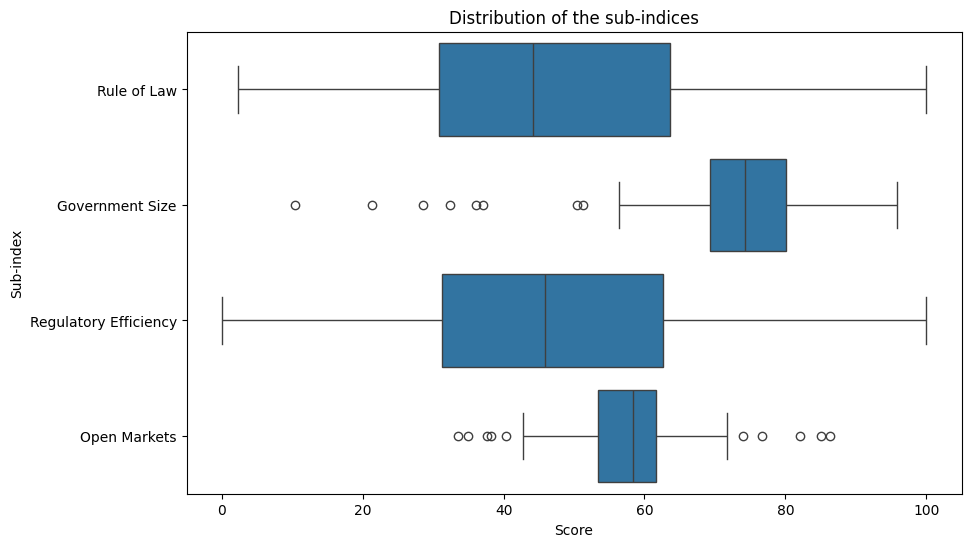

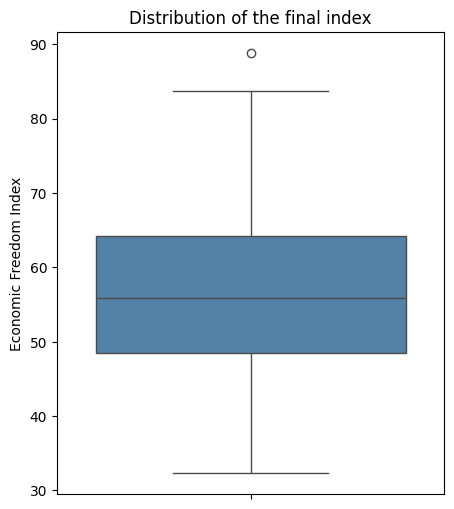

In [86]:
print("Top 10 countries in the index")
display(sub_index_data[["Rank", "country_name", "Economic Freedom Index", "Rule of Law", "Government Size", "Regulatory Efficiency", "Open Markets"]].head(10))

print("Bottom 10 countries in the index")
display(sub_index_data[["Rank", "country_name", "Economic Freedom Index", "Rule of Law", "Government Size", "Regulatory Efficiency", "Open Markets"]].tail(10))

sub_index_boxplot_data = sub_index_data[["Rule of Law", "Government Size", "Regulatory Efficiency", "Open Markets"]].melt(var_name="Sub-index", value_name="Score")

plt.figure(figsize=(10, 6))
sns.boxplot(data=sub_index_boxplot_data, x="Score", y="Sub-index")
plt.title("Distribution of the sub-indices")
plt.xlabel("Score")
plt.ylabel("Sub-index")
plt.show()

plt.figure(figsize=(5, 6))
sns.boxplot(y=sub_index_data["Economic Freedom Index"], color="steelblue")
plt.title("Distribution of the final index")
plt.ylabel("Economic Freedom Index")
plt.show()

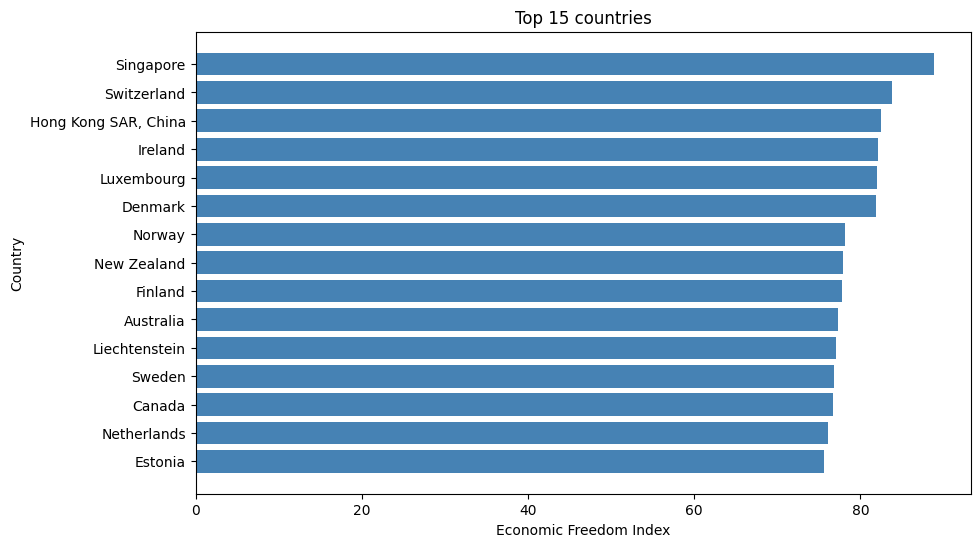

In [87]:
plt.figure(figsize=(10, 6))
top_plot = sub_index_data.head(15).sort_values("Economic Freedom Index")
plt.barh(top_plot["country_name"], top_plot["Economic Freedom Index"], color="steelblue")
plt.xlabel("Economic Freedom Index")
plt.ylabel("Country")
plt.title("Top 15 countries")
plt.show()

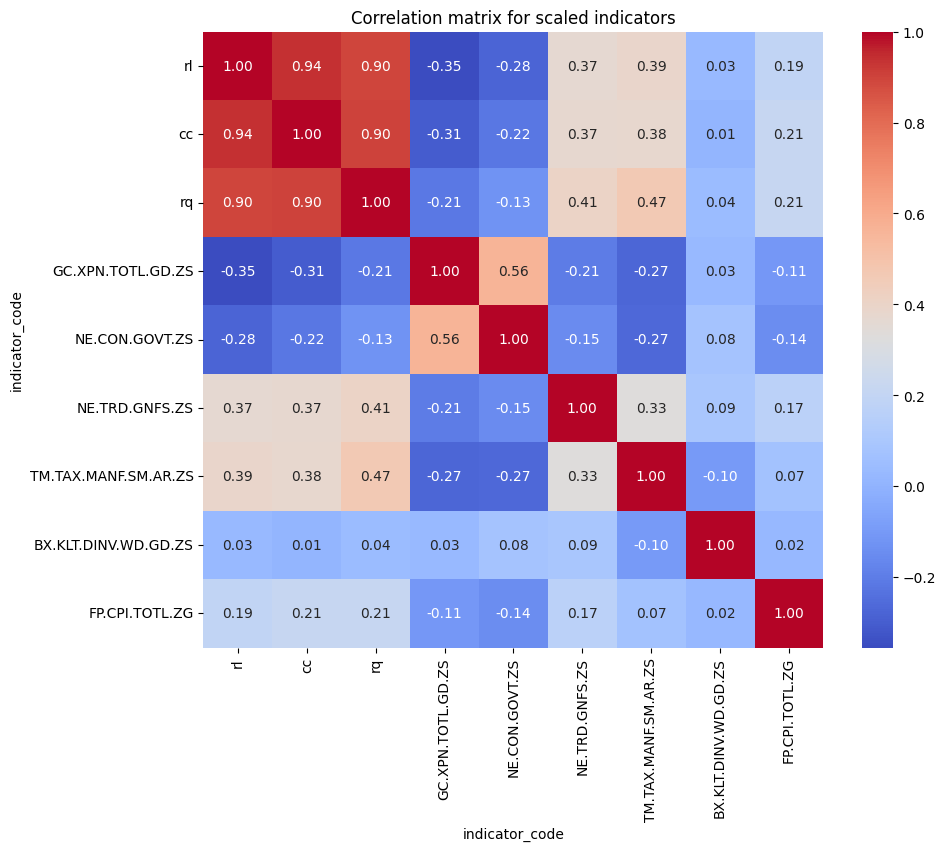

In [88]:
correlation_data = scaled_data[indicator_plan["indicator_code"].tolist()].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix for scaled indicators")
plt.show()

## 13. PCA

PCA is useful here for one main reason:
- it shows whether the simple index is broadly following the main common pattern in the indicator data

If the first principal component tells a similar story to the final index, that is a good sign that the index is not behaving in a strange way.

In [89]:
indicator_columns = indicator_plan["indicator_code"].tolist()
X = scaled_data[indicator_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca_scores = pca.fit_transform(X_scaled)

explained_variance = pd.DataFrame(
    {
        "principal_component": [f"PC{i}" for i in range(1, len(indicator_columns) + 1)],
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "explained_variance_percent": pca.explained_variance_ratio_ * 100,
    }
)

loadings = pd.DataFrame(
    pca.components_.T,
    index=indicator_columns,
    columns=[f"PC{i}" for i in range(1, len(indicator_columns) + 1)],
).reset_index().rename(columns={"index": "indicator_code"})

loadings = loadings.merge(
    indicator_plan[["indicator_code", "indicator_name", "dimension"]],
    on="indicator_code",
    how="left",
)

display(explained_variance.head(5))
display(loadings[["indicator_code", "indicator_name", "dimension", "PC1", "PC2"]].sort_values("PC1", ascending=False))

,principal_component,explained_variance_ratio,explained_variance_percent
0,PC1,0.41,40.62
1,PC2,0.15,15.24
2,PC3,0.12,11.55
3,PC4,0.10,10.27
4,PC5,0.09,9.32


,indicator_code,indicator_name,dimension,PC1,PC2
0,rl,Rule of law,Rule of Law,0.48,0.17
1,cc,Control of corruption,Rule of Law,0.48,0.21
2,rq,Regulatory quality,Regulatory Efficiency,0.47,0.29
6,TM.TAX.MANF.SM.AR.ZS,"Tariff rate, applied, simple mean, manufactured products (%)",Open Markets,0.31,-0.14
5,NE.TRD.GNFS.ZS,Trade (% of GDP),Open Markets,0.29,0.07
8,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",Open Markets,0.16,-0.02
7,BX.KLT.DINV.WD.GD.ZS,"Foreign direct investment, net inflows (% of GDP)",Open Markets,0.00,0.29
4,NE.CON.GOVT.ZS,General government final consumption expenditure (% of GDP),Government Size,-0.22,0.65
3,GC.XPN.TOTL.GD.ZS,Expense (% of GDP),Government Size,-0.27,0.56


Correlation between PC1 and the final Economic Freedom Index: 0.069


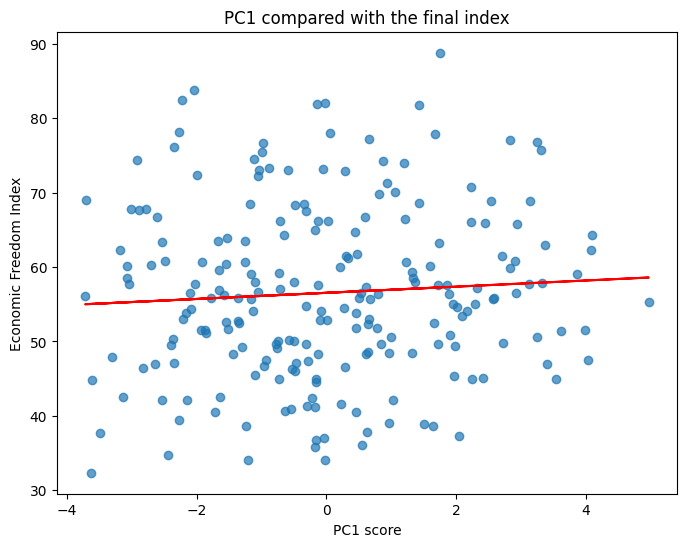

In [90]:
pc1_score = pca_scores[:, 0]

if np.corrcoef(pc1_score, sub_index_data["Economic Freedom Index"])[0, 1] < 0:
    pc1_score = -pc1_score

sub_index_data["PC1 score"] = pc1_score
sub_index_data["PC2 score"] = pca_scores[:, 1]

pc1_correlation = sub_index_data["PC1 score"].corr(sub_index_data["Economic Freedom Index"])
print("Correlation between PC1 and the final Economic Freedom Index:", round(pc1_correlation, 3))

plt.figure(figsize=(8, 6))
plt.scatter(sub_index_data["PC1 score"], sub_index_data["Economic Freedom Index"], alpha=0.7)
line = np.polyfit(sub_index_data["PC1 score"], sub_index_data["Economic Freedom Index"], 1)
plt.plot(sub_index_data["PC1 score"], np.poly1d(line)(sub_index_data["PC1 score"]), color="red")
plt.xlabel("PC1 score")
plt.ylabel("Economic Freedom Index")
plt.title("PC1 compared with the final index")
plt.show()

## 14. Clustering

Clustering is used here to answer a practical question:
- after the index is built, do countries fall into a few visible groups with similar profiles?

I will cluster countries using the four sub-indices, because the sub-indices are the main building blocks of the final index.

In [91]:
cluster_features = sub_index_data[["Rule of Law", "Government Size", "Regulatory Efficiency", "Open Markets"]]
cluster_scaled = StandardScaler().fit_transform(cluster_features)

cluster_diagnostics = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(cluster_scaled)
    cluster_diagnostics.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette_score": silhouette_score(cluster_scaled, labels),
        }
    )

cluster_diagnostics = pd.DataFrame(cluster_diagnostics)
display(cluster_diagnostics)

,k,inertia,silhouette_score
0,2,505.45,0.37
1,3,406.37,0.28
2,4,359.31,0.24
3,5,267.05,0.28
4,6,239.39,0.28


In [92]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
sub_index_data["cluster_id"] = kmeans.fit_predict(cluster_scaled)

cluster_order = sub_index_data.groupby("cluster_id")["Economic Freedom Index"].mean().sort_values().index.tolist()
cluster_names = {
    cluster_order[0]: "Lower freedom",
    cluster_order[1]: "Middle freedom",
    cluster_order[2]: "Higher freedom",
}

sub_index_data["freedom_group"] = sub_index_data["cluster_id"].map(cluster_names)

cluster_profile = sub_index_data.groupby("freedom_group")[["Rule of Law", "Government Size", "Regulatory Efficiency", "Open Markets", "Economic Freedom Index"]].mean().round(2)
display(cluster_profile)

print("Example countries in each cluster")
display(sub_index_data[["Rank", "country_name", "Economic Freedom Index", "freedom_group"]].head(15))

,Rule of Law,Government Size,Regulatory Efficiency,Open Markets,Economic Freedom Index
freedom_group,,,,,
Higher freedom,75.88,69.41,77.17,64.38,71.71
Lower freedom,25.79,80.42,27.10,51.13,46.11
Middle freedom,46.56,70.30,45.66,58.75,55.32


Example countries in each cluster


,Rank,country_name,Economic Freedom Index,freedom_group
0,1,Singapore,88.81,Higher freedom
1,2,Switzerland,83.77,Higher freedom
2,3,"Hong Kong SAR, China",82.51,Higher freedom
3,4,Ireland,82.11,Higher freedom
4,5,Luxembourg,81.95,Higher freedom
5,6,Denmark,81.85,Higher freedom
6,7,Norway,78.20,Higher freedom
7,8,New Zealand,77.97,Higher freedom
8,9,Finland,77.83,Higher freedom
9,10,Australia,77.28,Higher freedom


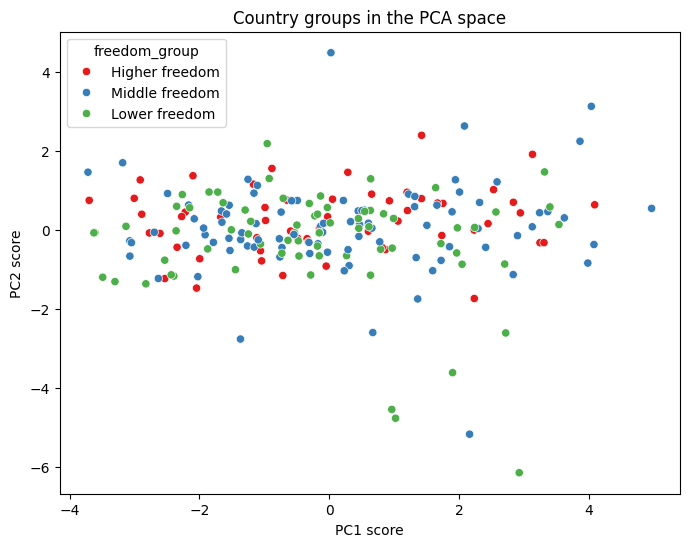

In [93]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sub_index_data,
    x="PC1 score",
    y="PC2 score",
    hue="freedom_group",
    palette="Set1",
)
plt.title("Country groups in the PCA space")
plt.show()

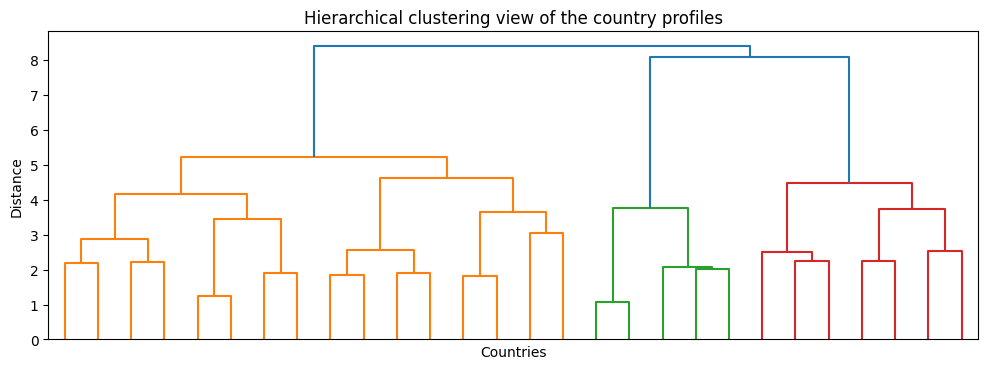

In [94]:
linked = linkage(cluster_scaled, method="complete")

plt.figure(figsize=(12, 4))
dendrogram(linked, no_labels=True, truncate_mode="level", p=4)
plt.title("Hierarchical clustering view of the country profiles")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.show()

## 15. Multiple Linear Regression

I also want to check whether the four sub-indices are carrying useful information together.

For that I use one external outcome variable from WDI:
- GDP per capita, PPP

I do **not** use GDP to build the index itself.

Instead, I use it as a check:
- do the sub-indices have a meaningful joint relationship with an economic outcome?
- are regression-based weights stable enough to use?

If the regression is unstable because the sub-indices overlap too much, then simple equal weighting is easier to justify.

In [95]:
gdp_cols = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"] + LOOKBACK_YEARS
gdp_raw = pd.read_csv("WDICSV.csv", usecols=gdp_cols)
gdp_raw = gdp_raw[gdp_raw["Country Code"].isin(country_meta["country_code"])]
gdp_raw = gdp_raw[gdp_raw["Indicator Code"] == "NY.GDP.PCAP.PP.KD"].copy()

display(gdp_raw.head(10))

,Country Name,Country Code,Indicator Name,Indicator Code,2019,2020,2021,2022,2023
74807,Afghanistan,AFG,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,2927.25,2769.69,2144.17,1981.71,1983.81
76323,Albania,ALB,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,16761.19,16457.79,18212.87,19388.87,20481.04
77839,Algeria,DZA,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,15199.20,14194.16,14496.87,14782.20,15159.32
79355,American Samoa,ASM,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN
80871,Andorra,AND,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,63215.90,55488.49,59332.20,63913.38,64631.30
82387,Angola,AGO,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,9648.01,8960.34,8862.28,8950.14,8788.26
83903,Antigua and Barbuda,ATG,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,29651.86,23930.67,25745.50,27941.79,28474.04
85419,Argentina,ARG,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,26629.55,23877.09,26300.27,27825.03,27230.40
86935,Armenia,ARM,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,16215.36,15052.94,15921.71,17886.18,19402.75
88451,Aruba,ABW,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,39652.63,30347.64,35104.79,38979.84,41964.77


In [96]:
gdp_long = gdp_raw.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=LOOKBACK_YEARS,
    var_name="year",
    value_name="gdp_per_capita_ppp",
)

gdp_long = gdp_long.dropna(subset=["gdp_per_capita_ppp"]).copy()
gdp_long["year"] = gdp_long["year"].astype(int)

gdp_latest = gdp_long.sort_values(["Country Code", "year"], ascending=[True, False]).drop_duplicates(["Country Code"])
gdp_latest = gdp_latest.rename(columns={"Country Name": "country_name", "Country Code": "country_code", "year": "gdp_year_used"})

display(gdp_latest.head(10))

,country_name,country_code,Indicator Name,Indicator Code,gdp_year_used,gdp_per_capita_ppp
877,Aruba,ABW,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,2023,41964.77
868,Afghanistan,AFG,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,2023,1983.81
873,Angola,AGO,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,2023,8788.26
869,Albania,ALB,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,2023,20481.04
872,Andorra,AND,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,2023,64631.30
1072,United Arab Emirates,ARE,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,2023,70239.86
875,Argentina,ARG,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,2023,27230.40
876,Armenia,ARM,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,2023,19402.75
874,Antigua and Barbuda,ATG,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,2023,28474.04
878,Australia,AUS,"GDP per capita, PPP (constant 2021 international $)",NY.GDP.PCAP.PP.KD,2023,60684.96


In [97]:
validation_data = sub_index_data.merge(
    gdp_latest[["country_code", "gdp_per_capita_ppp", "gdp_year_used"]],
    on="country_code",
    how="inner",
)

validation_data["log_gdp_per_capita_ppp"] = np.log(validation_data["gdp_per_capita_ppp"])

print("Countries in the regression sample:", len(validation_data))
display(validation_data[["country_name", "Economic Freedom Index", "gdp_per_capita_ppp", "gdp_year_used"]].head(10))

correlation_with_gdp = validation_data[["Rule of Law", "Government Size", "Regulatory Efficiency", "Open Markets", "Economic Freedom Index", "log_gdp_per_capita_ppp"]].corr()
display(correlation_with_gdp[["log_gdp_per_capita_ppp"]].sort_values("log_gdp_per_capita_ppp", ascending=False))

Countries in the regression sample: 204


,country_name,Economic Freedom Index,gdp_per_capita_ppp,gdp_year_used
0,Singapore,88.81,129555.25,2023
1,Switzerland,83.77,82295.30,2023
2,"Hong Kong SAR, China",82.51,64434.56,2023
3,Ireland,82.11,117862.13,2023
4,Luxembourg,81.95,130048.92,2023
5,Denmark,81.85,69379.22,2023
6,Norway,78.20,90085.44,2023
7,New Zealand,77.97,49508.27,2023
8,Finland,77.83,56250.88,2023
9,Australia,77.28,60684.96,2023


,log_gdp_per_capita_ppp
log_gdp_per_capita_ppp,1.00
Regulatory Efficiency,0.78
Economic Freedom Index,0.75
Rule of Law,0.69
Open Markets,0.52
Government Size,-0.19


In [98]:
X_reg = validation_data[["Rule of Law", "Government Size", "Regulatory Efficiency", "Open Markets"]].copy()
y_reg = validation_data["log_gdp_per_capita_ppp"].copy()

X_reg = (X_reg - X_reg.mean()) / X_reg.std()
y_reg = (y_reg - y_reg.mean()) / y_reg.std()

X_reg_const = sm.add_constant(X_reg)
mlr_model = sm.OLS(y_reg, X_reg_const).fit()
print(mlr_model.summary())

vif_table = pd.DataFrame()
vif_table["feature"] = X_reg_const.columns
vif_table["VIF"] = [variance_inflation_factor(X_reg_const.values, i) for i in range(len(X_reg_const.columns))]
display(vif_table)

                              OLS Regression Results                              
Dep. Variable:     log_gdp_per_capita_ppp   R-squared:                       0.614
Model:                                OLS   Adj. R-squared:                  0.606
Method:                     Least Squares   F-statistic:                     78.97
Date:                    Sat, 11 Apr 2026   Prob (F-statistic):           5.17e-40
Time:                            18:35:29   Log-Likelihood:                -192.00
No. Observations:                     204   AIC:                             394.0
Df Residuals:                         199   BIC:                             410.6
Df Model:                               4                                         
Covariance Type:                nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

,feature,VIF
0,const,1.00
1,Rule of Law,7.25
2,Government Size,1.37
3,Regulatory Efficiency,7.74
4,Open Markets,1.66


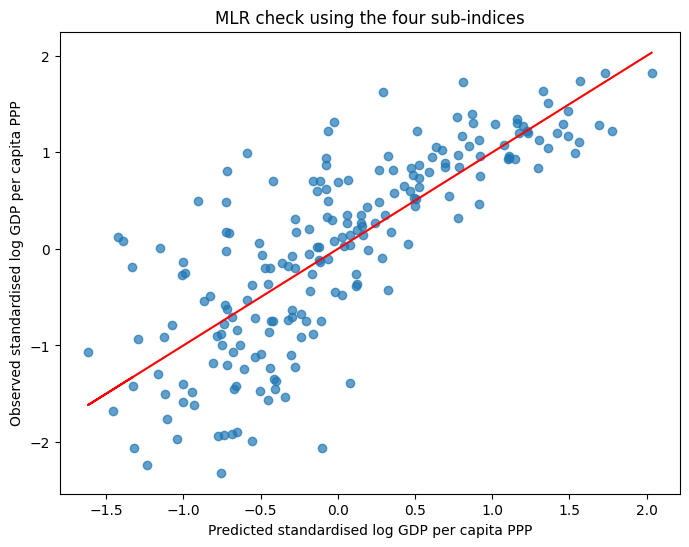

R-squared from the multiple regression: 0.614
Adjusted R-squared from the multiple regression: 0.606


In [99]:
validation_data["predicted_log_gdp"] = mlr_model.predict(X_reg_const)

plt.figure(figsize=(8, 6))
plt.scatter(validation_data["predicted_log_gdp"], y_reg, alpha=0.7)
line = np.polyfit(validation_data["predicted_log_gdp"], y_reg, 1)
plt.plot(validation_data["predicted_log_gdp"], np.poly1d(line)(validation_data["predicted_log_gdp"]), color="red")
plt.xlabel("Predicted standardised log GDP per capita PPP")
plt.ylabel("Observed standardised log GDP per capita PPP")
plt.title("MLR check using the four sub-indices")
plt.show()

print("R-squared from the multiple regression:", round(mlr_model.rsquared, 3))
print("Adjusted R-squared from the multiple regression:", round(mlr_model.rsquared_adj, 3))

### Short interpretation of the MLR step

This regression step is useful for the index design in two ways.

First, it shows that the sub-indices together carry meaningful information about a country outcome variable.

Second, it helps with the weighting decision:
- if the regression coefficients were very clean and independent, I could consider regression-based weights
- if the coefficients are unstable because the sub-indices overlap, then simple equal weighting is the safer choice

In this notebook I keep **equal weighting** for the final index because it is easier to explain and it avoids turning the index into a hidden regression model.

## 16. Final ranking

The table below is the final country ranking.

It includes:
- the four sub-indices
- the final Economic Freedom Index
- the cluster-based freedom group

In [100]:
final_ranking = sub_index_data[[
    "Rank",
    "country_name",
    "country_code",
    "region",
    "income_group",
    "Rule of Law",
    "Government Size",
    "Regulatory Efficiency",
    "Open Markets",
    "Economic Freedom Index",
    "freedom_group",
]].copy()

final_ranking = final_ranking.rename(
    columns={
        "country_name": "Country Name",
        "country_code": "Country Code",
        "region": "Region",
        "income_group": "Income Group",
        "freedom_group": "Freedom Group",
    }
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(final_ranking)

final_ranking.to_csv("economic_freedom_ranking.csv", index=False)
print("Saved final table to economic_freedom_ranking.csv")

,Rank,Country Name,Country Code,Region,Income Group,Rule of Law,Government Size,Regulatory Efficiency,Open Markets,Economic Freedom Index,Freedom Group
0,1,Singapore,SGP,East Asia & Pacific,High income,88.26,84.84,100.00,82.14,88.81,Higher freedom
1,2,Switzerland,CHE,Europe & Central Asia,High income,94.68,83.97,92.21,64.23,83.77,Higher freedom
2,3,"Hong Kong SAR, China",HKG,East Asia & Pacific,High income,77.34,77.31,90.41,84.99,82.51,Higher freedom
3,4,Ireland,IRL,Europe & Central Asia,High income,86.28,82.23,92.01,67.91,82.11,Higher freedom
4,5,Luxembourg,LUX,Europe & Central Asia,High income,92.92,65.18,92.97,76.75,81.95,Higher freedom
5,6,Denmark,DNK,Europe & Central Asia,High income,99.93,65.56,96.63,65.28,81.85,Higher freedom
6,7,Norway,NOR,Europe & Central Asia,High income,96.70,64.85,88.11,63.14,78.20,Higher freedom
7,8,New Zealand,NZL,East Asia & Pacific,High income,92.70,66.10,93.92,59.14,77.97,Higher freedom
8,9,Finland,FIN,Europe & Central Asia,High income,98.53,57.22,93.68,61.87,77.83,Higher freedom
9,10,Australia,AUS,East Asia & Pacific,High income,87.78,69.59,92.39,59.35,77.28,Higher freedom


Saved final table to economic_freedom_ranking.csv


## 17. Conclusion

This notebook built a country-level Economic Freedom Index from raw local data in a visible sequence.

The main choices were:
- use WDI for economic indicators and WGI for governance indicators
- keep only countries, not regional aggregates
- use the latest available value up to 2023
- fill remaining gaps with indicator medians
- reverse the indicators where lower values are better
- rescale everything to 0-100
- average indicators into four sub-indices
- average the four sub-indices into the final index

The extra analysis steps were used with a purpose:
- **PCA** checked whether the final index follows the main pattern in the indicator data
- **Clustering** grouped countries with similar economic freedom profiles
- **MLR** checked whether the sub-indices jointly carry useful information and helped justify keeping equal weights instead of regression weights

So the final output is not just a ranking. It is a full path from raw indicators to a final composite index.